In [4]:
import yfinance as yf
import datetime
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import acf

import random

import utils

from tqdm import tqdm

In [65]:
ticker = yf.Ticker('NVDA')



end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(59)


ticker_hist = ticker.history(interval = '2m', start = start_date ,end=end_date)

ticker_hist = ticker_hist.reset_index()

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

counts, bin_edges = np.histogram(ticker_hist['logReturns'], bins=100)

In [66]:
(ticker_hist['Volume'] * ticker_hist['logReturns']).sum()/ticker_hist['Volume'].sum()
mu = (ticker_hist['Volume'] * ticker_hist['logReturns']).sum()/ticker_hist['Volume'].sum()


In [67]:
var = (ticker_hist['Volume']*(ticker_hist['logReturns'] - mu)**2).sum() / ticker_hist['Volume'].sum()

In [68]:
var

np.float64(7.227328255847503e-06)

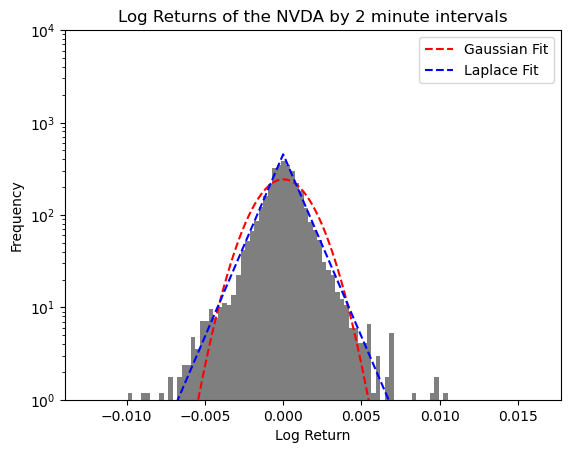

In [74]:
plt.hist(ticker_hist['logReturns'], bins = 100, density = True, fc = 'black', alpha = 0.5)
plt.yscale('log')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.title('Log Returns of the NVDA by 2 minute intervals')

mu = (ticker_hist['Volume'] * ticker_hist['logReturns']).sum()/ticker_hist['Volume'].sum()
var = (ticker_hist['Volume']*(ticker_hist['logReturns'] - mu)**2).sum() / ticker_hist['Volume'].sum()

mu = ticker_hist['logReturns'].mean()
var = ticker_hist['logReturns'].std()**2

x = np.arange(-0.01, 0.01, 0.0001)

plt.plot(x, 1/(np.sqrt(2 * np.pi * var)) * np.exp(- (x - mu)**2/(2*var)), color = 'red', ls= '--', label = 'Gaussian Fit')

a = np.median(ticker_hist['logReturns'])
b = np.mean(np.abs(ticker_hist['logReturns'] - a))

plt.plot(x, 1/(2*b) * np.exp(-np.abs(x - a)/b), color = 'blue', ls = '--', label = 'Laplace Fit')

plt.legend(loc = 'best')
plt.ylim(10**0, 10**4)
plt.savefig('unvolume_weighted_60_day_distro.pdf', bbox_inches = 'tight')
plt.show()

In [70]:
b

np.float64(0.0011010800759638259)

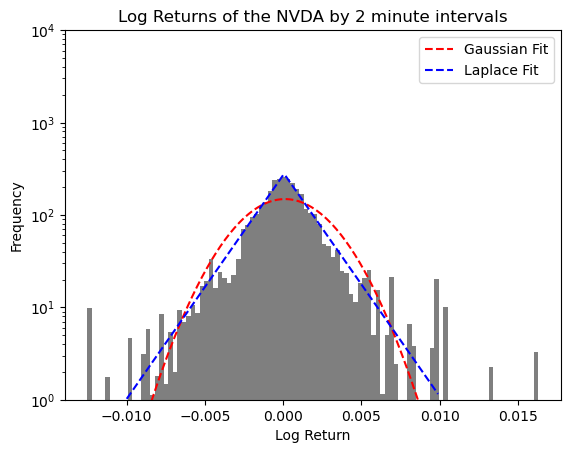

In [75]:
plt.hist(ticker_hist['logReturns'], weights = ticker_hist['Volume'], bins = 100, density = True, fc = 'black', alpha = 0.5)
plt.yscale('log')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.title('Log Returns of the NVDA by 2 minute intervals')

mu = (ticker_hist['Volume'] * ticker_hist['logReturns']).sum()/ticker_hist['Volume'].sum()
var = (ticker_hist['Volume']*(ticker_hist['logReturns'] - mu)**2).sum() / ticker_hist['Volume'].sum()

#mu = ticker_hist['logReturns'].mean()
#var = ticker_hist['logReturns'].std()**2

x = np.arange(-0.01, 0.01, 0.0001)

plt.plot(x, 1/(np.sqrt(2 * np.pi * var)) * np.exp(- (x - mu)**2/(2*var)), color = 'red', ls= '--', label = 'Gaussian Fit')

#a = np.median(ticker_hist['logReturns'])
#b = np.mean(np.abs(ticker_hist['logReturns'] - a))

ticker_hist_date = ticker_hist.sort_values('logReturns')

ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['Volume'].cumsum()/ticker_hist_date['Volume'].sum()
a = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]

b = np.sum(np.abs(ticker_hist_date['logReturns'] - a)*ticker_hist_date['Volume']) / ticker_hist_date['Volume'].sum()



plt.plot(x, 1/(2*b) * np.exp(-np.abs(x - a)/b), color = 'blue', ls = '--', label = 'Laplace Fit')

plt.legend(loc = 'best')
plt.ylim(10**0, 10**4)
plt.savefig('volume_weighted_60_day_distro.pdf', bbox_inches = 'tight')
plt.show()

In [7]:
def laplace_fit(x, b, a):
    return 1/(2*b) * np.exp(-np.abs(x - a) / b)

In [8]:
import scipy

((b, a), cov) = scipy.optimize.curve_fit(laplace_fit, bin_edges[:-1] + np.diff(bin_edges)[0]/2, counts/sum(counts)/np.diff(bin_edges)[0])

In [9]:
ticker

yfinance.Ticker object <SPY>

In [10]:
a = np.median(ticker_hist['logReturns'])
b = np.mean(np.absolute(ticker_hist['logReturns'] - a))

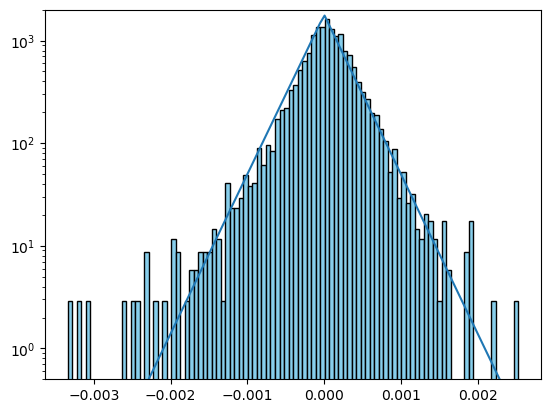

In [11]:
plt.bar(
    x=bin_edges[:-1] + np.diff(bin_edges)[0]/2, 
    height=counts/(sum(counts)*np.diff(bin_edges)[0]),
    width=np.diff(bin_edges), 
    align='edge', 
    fc='skyblue', 
    ec='black'
)
#plt.xlim((bin_edges[0], bin_edges[-1]))
plt.plot(bin_edges[:-1] + np.diff(bin_edges)[0]/2, laplace_fit(bin_edges[:-1] + np.diff(bin_edges)[0]/2 , b, a))
plt.ylim(0.5, 2000)
plt.yscale('log')

In [26]:
ab_params = np.zeros((len(ticker_hist['Date'].unique()), 2))

for index, date in enumerate(ticker_hist['Date'].unique()):
    counts, bin_edges = np.histogram(ticker_hist[ticker_hist['Date'] == date]['logReturns'], bins=100)
    
    ab_params[index, 1] = np.median(ticker_hist[ticker_hist['Date'] == date]['logReturns'])
    ab_params[index, 0] = np.mean(
        np.abs(ticker_hist[ticker_hist['Date'] == date]['logReturns'] - ab_params[index, 1])
    )
    

In [27]:
ticker_hist

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Date,Time,logClose,logOpen,logReturns
0,2024-07-26 09:30:00-04:00,542.280029,542.429993,541.489990,541.559998,2939784,0.0,0.0,0.0,2024-07-26,09:30:00,6.294454,6.295783,-0.001329
1,2024-07-26 09:32:00-04:00,541.542297,542.409485,541.539978,542.159973,301178,0.0,0.0,0.0,2024-07-26,09:32:00,6.295561,6.294421,0.001140
2,2024-07-26 09:34:00-04:00,542.119995,542.484985,541.840027,542.229980,371156,0.0,0.0,0.0,2024-07-26,09:34:00,6.295690,6.295487,0.000203
3,2024-07-26 09:36:00-04:00,542.219971,543.039978,542.080078,542.669983,327913,0.0,0.0,0.0,2024-07-26,09:36:00,6.296501,6.295672,0.000830
4,2024-07-26 09:38:00-04:00,542.669983,542.950012,542.662720,542.940002,294071,0.0,0.0,0.0,2024-07-26,09:38:00,6.296999,6.296501,0.000497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6257,2024-09-11 10:14:00-04:00,543.570007,543.570007,541.679993,541.770020,774076,0.0,0.0,0.0,2024-09-11,10:14:00,6.294842,6.298159,-0.003317
6258,2024-09-11 10:16:00-04:00,541.707520,542.119995,541.450073,541.556580,608877,0.0,0.0,0.0,2024-09-11,10:16:00,6.294448,6.294726,-0.000279
6259,2024-09-11 10:18:00-04:00,541.590027,541.919983,541.440002,541.539978,579959,0.0,0.0,0.0,2024-09-11,10:18:00,6.294417,6.294509,-0.000092
6260,2024-09-11 10:20:00-04:00,541.619995,541.619995,541.200012,541.330017,625220,0.0,0.0,0.0,2024-09-11,10:20:00,6.294029,6.294565,-0.000536


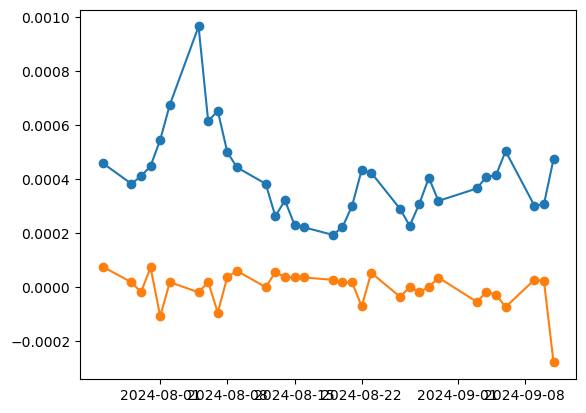

In [28]:
plt.scatter(ticker_hist['Date'].unique(), ab_params[:,0])
plt.plot(ticker_hist['Date'].unique(), ab_params[:,0])
plt.scatter(ticker_hist['Date'].unique(), ab_params[:,1])

plt.plot(ticker_hist['Date'].unique(), ab_params[:,1])


(array([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 2., 4., 1., 5., 6.,
        3., 1., 2.]),
 array([-3.31691341e-03, -3.12452731e-03, -2.93214122e-03, -2.73975512e-03,
        -2.54736903e-03, -2.35498293e-03, -2.16259684e-03, -1.97021074e-03,
        -1.77782465e-03, -1.58543855e-03, -1.39305246e-03, -1.20066636e-03,
        -1.00828027e-03, -8.15894170e-04, -6.23508075e-04, -4.31121980e-04,
        -2.38735885e-04, -4.63497899e-05,  1.46036305e-04,  3.38422400e-04,
         5.30808495e-04]),
 <BarContainer object of 20 artists>)

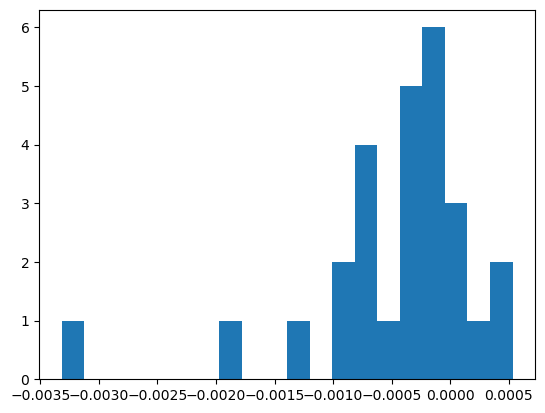

In [29]:
plt.hist(ticker_hist[ticker_hist['Date'] == date]['logReturns'], bins=20)

In [30]:
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


In [31]:
tickers

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [40]:
ticker_hist['Date'].unique()

array([datetime.date(2024, 7, 29), datetime.date(2024, 7, 30),
       datetime.date(2024, 7, 31), datetime.date(2024, 8, 1),
       datetime.date(2024, 8, 2), datetime.date(2024, 8, 5),
       datetime.date(2024, 8, 6), datetime.date(2024, 8, 7),
       datetime.date(2024, 8, 8), datetime.date(2024, 8, 9),
       datetime.date(2024, 8, 12), datetime.date(2024, 8, 13),
       datetime.date(2024, 8, 14), datetime.date(2024, 8, 15),
       datetime.date(2024, 8, 16), datetime.date(2024, 8, 19),
       datetime.date(2024, 8, 20), datetime.date(2024, 8, 21),
       datetime.date(2024, 8, 22), datetime.date(2024, 8, 23),
       datetime.date(2024, 8, 26), datetime.date(2024, 8, 27),
       datetime.date(2024, 8, 28), datetime.date(2024, 8, 29),
       datetime.date(2024, 8, 30), datetime.date(2024, 9, 3),
       datetime.date(2024, 9, 4), datetime.date(2024, 9, 5),
       datetime.date(2024, 9, 6), datetime.date(2024, 9, 9),
       datetime.date(2024, 9, 10), datetime.date(2024, 9, 11)],
   

In [44]:
test = yf.Ticker('MMM').history(interval = '2m', start = start_date, end = end_date).dropna().reset_index()

In [45]:
test

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2024-07-26 09:30:00-04:00,112.684998,115.000000,112.684998,114.019997,720294,0.0,0.0
1,2024-07-26 09:32:00-04:00,113.995003,117.269997,113.470299,117.019997,715326,0.0,0.0
2,2024-07-26 09:34:00-04:00,116.489998,119.529900,115.900002,117.425003,713399,0.0,0.0
3,2024-07-26 09:36:00-04:00,117.419998,117.980003,116.809998,117.160004,352686,0.0,0.0
4,2024-07-26 09:38:00-04:00,117.160004,117.889999,116.529999,116.800003,353677,0.0,0.0
...,...,...,...,...,...,...,...,...
6258,2024-09-11 10:16:00-04:00,127.980003,128.149994,127.830002,127.849998,13127,0.0,0.0
6259,2024-09-11 10:18:00-04:00,127.900002,127.947899,127.800003,127.870003,9068,0.0,0.0
6260,2024-09-11 10:20:00-04:00,127.790001,127.790001,127.450104,127.519997,26656,0.0,0.0
6261,2024-09-11 10:22:00-04:00,127.519997,127.680000,127.480003,127.609901,10303,0.0,0.0


In [46]:
test['Date'] = test.apply(lambda row: row['Datetime'].date(), axis=1)
test['Time'] = test.apply(lambda row: row['Datetime'].time(), axis=1)

In [47]:
test['Date'].unique()

array([datetime.date(2024, 7, 26), datetime.date(2024, 7, 29),
       datetime.date(2024, 7, 30), datetime.date(2024, 7, 31),
       datetime.date(2024, 8, 1), datetime.date(2024, 8, 2),
       datetime.date(2024, 8, 5), datetime.date(2024, 8, 6),
       datetime.date(2024, 8, 7), datetime.date(2024, 8, 8),
       datetime.date(2024, 8, 9), datetime.date(2024, 8, 12),
       datetime.date(2024, 8, 13), datetime.date(2024, 8, 14),
       datetime.date(2024, 8, 15), datetime.date(2024, 8, 16),
       datetime.date(2024, 8, 19), datetime.date(2024, 8, 20),
       datetime.date(2024, 8, 21), datetime.date(2024, 8, 22),
       datetime.date(2024, 8, 23), datetime.date(2024, 8, 26),
       datetime.date(2024, 8, 27), datetime.date(2024, 8, 28),
       datetime.date(2024, 8, 29), datetime.date(2024, 8, 30),
       datetime.date(2024, 9, 3), datetime.date(2024, 9, 4),
       datetime.date(2024, 9, 5), datetime.date(2024, 9, 6),
       datetime.date(2024, 9, 9), datetime.date(2024, 9, 10),
    

In [49]:
ticker = yf.Ticker('ZTS')

end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(60)

ticker_hist = ticker.history(interval = '2m', start = start_date ,end=end_date).dropna()

In [50]:
ticker_hist

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-07-29 09:30:00-04:00,180.630005,180.630005,179.794998,179.794998,32456,0.0,0.0
2024-07-29 09:32:00-04:00,179.794998,179.794998,179.199997,179.389999,14566,0.0,0.0
2024-07-29 09:34:00-04:00,179.345001,179.649994,179.179993,179.404999,19076,0.0,0.0
2024-07-29 09:36:00-04:00,179.199997,179.949997,179.149994,179.949997,9007,0.0,0.0
2024-07-29 09:38:00-04:00,179.919998,180.360001,179.641205,179.820007,4082,0.0,0.0
...,...,...,...,...,...,...,...
2024-09-11 10:48:00-04:00,187.554993,187.554993,187.535004,187.535004,5159,0.0,0.0
2024-09-11 10:52:00-04:00,187.814606,187.858200,187.789993,187.850006,1388,0.0,0.0
2024-09-11 10:54:00-04:00,187.747696,187.929993,187.699997,187.794998,9640,0.0,0.0


In [56]:
start_date

datetime.datetime(2024, 7, 14, 11, 8, 3, 13683)

In [129]:
ticker_hist[ticker_hist['Date'] == date]['logClose'].iloc[-1] - ticker_hist[ticker_hist['Date'] == date]['logOpen'].iloc[0]

np.float64(0.015276077004999777)

In [130]:
a_params = {}
b_params = {}
for symbol in tickers['Symbol']:
    ticker = yf.Ticker(symbol)

    end_date = datetime.datetime.now()
    start_date = end_date - datetime.timedelta(30)
    
    
    ticker_hist = ticker.history(interval = '2m', start = start_date ,end=end_date).dropna()

    if len(ticker_hist)>0:
        ticker_hist = ticker_hist.reset_index()
        
        ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
        ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)
        
        
        ticker_hist['logClose'] = np.log(ticker_hist['Close'])
        ticker_hist['logOpen'] = np.log(ticker_hist['Open'])
        
        ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']
    
        a_params[symbol] = []
        b_params[symbol] = []
        
        for index, date in enumerate(ticker_hist['Date'].unique()):
            ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
            counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
            a = (ticker_hist_date['logClose'].iloc[-1] - ticker_hist_date['logOpen'].iloc[0])/len(ticker_hist_date)
            b = np.mean(
                    np.abs(ticker_hist_date['logReturns'] - a)
            )
            a_params[symbol].append(a)
            b_params[symbol].append(b)
    

$BRK.B: possibly delisted; No timezone found
$BF.B: possibly delisted; No price data found  (2m 2024-08-12 17:53:34.592325 -> 2024-09-11 17:53:34.592325)


$BF.B: possibly delisted; No price data found  (2m 2024-08-12 17:53:34.592325 -> 2024-09-11 17:53:34.592325)


In [131]:
for key in a_params.keys():
    if len(a_params[key]) != len(a_params['MMM']):
        print(key)

In [132]:
a_params_df = pd.DataFrame(a_params)
b_params_df = pd.DataFrame(b_params)
a_row_names = {}
b_row_names = {}
row_names = {}

for i in range(len(ticker_hist['Date'].unique())):
    row_names[i] = str(list(ticker_hist['Date'].unique())[i])
    a_row_names[i] = str(list(ticker_hist['Date'].unique())[i]) + '_a'
    b_row_names[i] = str(list(ticker_hist['Date'].unique())[i]) + '_b'

a_params_df = a_params_df.rename(index = {i : row_names[i] for i in range(len(row_names))})
b_params_df = b_params_df.rename(index = {i : row_names[i] for i in range(len(row_names))})


In [133]:
a_params_df.T

,2024-08-13,2024-08-14,2024-08-15,2024-08-16,2024-08-19,2024-08-20,2024-08-21,2024-08-22,2024-08-23,2024-08-26,...,2024-08-28,2024-08-29,2024-08-30,2024-09-03,2024-09-04,2024-09-05,2024-09-06,2024-09-09,2024-09-10,2024-09-11
MMM,0.000078,0.000045,-0.000005,1.299830e-05,-8.073189e-07,0.000029,0.000055,-0.000018,0.000052,8.710041e-05,...,8.189481e-06,5.154805e-05,0.000047,-0.000083,3.622508e-05,-0.000058,-7.481360e-05,-0.000056,0.000049,0.000025
AOS,0.000005,-0.000014,-0.000040,-3.318268e-05,5.346462e-05,0.000011,0.000050,-0.000046,0.000047,-3.840563e-05,...,7.804745e-06,-2.004098e-05,0.000081,-0.000145,-5.129544e-05,-0.000132,-7.557292e-05,0.000040,0.000037,-0.000004
ABT,0.000021,0.000085,0.000022,-1.715523e-05,4.118308e-05,-0.000048,0.000018,0.000016,0.000012,-6.823530e-07,...,-8.622031e-06,-2.336417e-05,0.000012,0.000060,-1.388022e-05,-0.000052,1.397171e-05,0.000088,0.000040,0.000007
ABBV,0.000016,0.000052,-0.000028,5.314155e-07,9.171612e-05,-0.000024,0.000002,-0.000012,0.000006,-2.077085e-06,...,-9.181773e-07,-2.097436e-05,0.000026,0.000041,-4.354731e-05,-0.000110,-2.649259e-07,0.000038,0.000083,-0.000073
ACN,0.000053,-0.000006,0.000045,3.178372e-05,2.748055e-05,0.000007,0.000042,-0.000048,0.000026,6.168704e-05,...,-4.765382e-05,1.548338e-07,0.000012,0.000010,5.789075e-05,-0.000050,-1.492345e-05,0.000022,0.000058,0.000055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.000106,-0.000011,0.000009,-7.027469e-06,5.160261e-05,-0.000010,0.000047,-0.000019,0.000019,-3.769406e-05,...,3.036452e-06,-1.533443e-05,0.000058,-0.000134,-2.152060e-05,-0.000039,-5.434129e-05,0.000067,0.000013,0.000006
YUM,0.000059,-0.000008,-0.000004,-2.096650e-05,-3.869609e-05,0.000001,0.000017,-0.000043,-0.000074,-3.596618e-05,...,3.413736e-05,-2.156828e-05,-0.000021,-0.000041,3.244405e-05,-0.000011,-2.217530e-05,-0.000030,-0.000007,0.000058
ZBRA,0.000167,0.000029,0.000085,4.112220e-05,8.097166e-05,-0.000026,-0.000076,-0.000112,0.000226,-9.302458e-05,...,-2.552243e-05,-6.569884e-05,-0.000002,-0.000236,-6.861502e-07,0.000059,-1.953783e-04,0.000151,0.000161,0.000081
ZBH,0.000113,-0.000047,0.000044,3.685151e-05,5.300567e-05,-0.000011,0.000005,0.000028,0.000047,-3.291101e-05,...,-2.586949e-05,-1.140207e-05,0.000024,0.000038,-6.869805e-05,-0.000202,-3.364700e-05,-0.000010,0.000018,0.000024


In [134]:
a_b_params_concat = pd.concat([a_params_df.T, b_params_df.T]).T
targets = a_b_params_concat.shift(-1)

In [136]:
a_b_params_concat

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2024-08-13,7.833886e-05,0.000005,2.088860e-05,1.638965e-05,5.261581e-05,0.000041,0.000112,-0.000005,0.000012,6.125157e-05,...,0.000507,0.000512,0.000303,0.000678,0.000583,0.000534,0.000519,0.000561,0.000542,0.000628
2024-08-14,4.534832e-05,-0.000014,8.471134e-05,5.224986e-05,-5.612142e-06,0.000030,-0.000083,0.000000,0.000016,-7.650322e-05,...,0.000504,0.000549,0.000422,0.000662,0.000531,0.000435,0.000448,0.000511,0.000610,0.000672
2024-08-15,-5.238715e-06,-0.000040,2.177197e-05,-2.829126e-05,4.522475e-05,0.000082,0.000150,0.000097,-0.000006,8.240765e-05,...,0.000511,0.000398,0.000252,0.000735,0.000551,0.000514,0.000407,0.000411,0.000506,0.000588
2024-08-16,1.299830e-05,-0.000033,-1.715523e-05,5.314155e-07,3.178372e-05,0.000012,0.000100,0.000001,0.000095,9.076340e-06,...,0.000539,0.000390,0.000202,0.000613,0.000511,0.000430,0.000390,0.000378,0.000346,0.000437
2024-08-19,-8.073189e-07,0.000053,4.118308e-05,9.171612e-05,2.748055e-05,0.000115,0.000236,0.000039,0.000029,-1.824771e-06,...,0.000428,0.000405,0.000294,0.000554,0.000389,0.000490,0.000352,0.000430,0.000392,0.000424
2024-08-20,2.899351e-05,0.000011,-4.791893e-05,-2.358851e-05,6.679159e-06,-0.000024,-0.000009,0.000030,-0.000020,-3.146375e-05,...,0.000458,0.000492,0.000234,0.000484,0.000376,0.000359,0.000343,0.000499,0.000439,0.000392
2024-08-21,5.545783e-05,0.000050,1.799126e-05,1.566040e-06,4.205092e-05,0.000033,0.000052,0.000067,0.000045,7.365870e-07,...,0.000422,0.000463,0.000201,0.000487,0.000369,0.000442,0.000320,0.000427,0.000357,0.000463
2024-08-22,-1.750795e-05,-0.000046,1.557317e-05,-1.237974e-05,-4.830038e-05,-0.000089,-0.000235,0.000033,0.000063,-1.818583e-04,...,0.000522,0.000405,0.000276,0.000480,0.000383,0.000411,0.000354,0.000441,0.000428,0.000522
2024-08-23,5.172263e-05,0.000047,1.230372e-05,5.976062e-06,2.562212e-05,-0.000066,0.000043,0.000057,0.000016,-1.608664e-05,...,0.000607,0.000439,0.000396,0.000600,0.000391,0.000485,0.000385,0.000482,0.000399,0.000479
2024-08-26,8.710041e-05,-0.000038,-6.823530e-07,-2.077085e-06,6.168704e-05,0.000042,-0.000158,-0.000078,0.000002,-2.219329e-05,...,0.000492,0.000418,0.000243,0.000428,0.000468,0.000414,0.000330,0.000389,0.000347,0.000421


In [135]:
targets

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2024-08-13,4.534832e-05,-0.000014,8.471134e-05,5.224986e-05,-5.612142e-06,0.000030,-0.000083,0.000000,0.000016,-7.650322e-05,...,0.000504,0.000549,0.000422,0.000662,0.000531,0.000435,0.000448,0.000511,0.000610,0.000672
2024-08-14,-5.238715e-06,-0.000040,2.177197e-05,-2.829126e-05,4.522475e-05,0.000082,0.000150,0.000097,-0.000006,8.240765e-05,...,0.000511,0.000398,0.000252,0.000735,0.000551,0.000514,0.000407,0.000411,0.000506,0.000588
2024-08-15,1.299830e-05,-0.000033,-1.715523e-05,5.314155e-07,3.178372e-05,0.000012,0.000100,0.000001,0.000095,9.076340e-06,...,0.000539,0.000390,0.000202,0.000613,0.000511,0.000430,0.000390,0.000378,0.000346,0.000437
2024-08-16,-8.073189e-07,0.000053,4.118308e-05,9.171612e-05,2.748055e-05,0.000115,0.000236,0.000039,0.000029,-1.824771e-06,...,0.000428,0.000405,0.000294,0.000554,0.000389,0.000490,0.000352,0.000430,0.000392,0.000424
2024-08-19,2.899351e-05,0.000011,-4.791893e-05,-2.358851e-05,6.679159e-06,-0.000024,-0.000009,0.000030,-0.000020,-3.146375e-05,...,0.000458,0.000492,0.000234,0.000484,0.000376,0.000359,0.000343,0.000499,0.000439,0.000392
2024-08-20,5.545783e-05,0.000050,1.799126e-05,1.566040e-06,4.205092e-05,0.000033,0.000052,0.000067,0.000045,7.365870e-07,...,0.000422,0.000463,0.000201,0.000487,0.000369,0.000442,0.000320,0.000427,0.000357,0.000463
2024-08-21,-1.750795e-05,-0.000046,1.557317e-05,-1.237974e-05,-4.830038e-05,-0.000089,-0.000235,0.000033,0.000063,-1.818583e-04,...,0.000522,0.000405,0.000276,0.000480,0.000383,0.000411,0.000354,0.000441,0.000428,0.000522
2024-08-22,5.172263e-05,0.000047,1.230372e-05,5.976062e-06,2.562212e-05,-0.000066,0.000043,0.000057,0.000016,-1.608664e-05,...,0.000607,0.000439,0.000396,0.000600,0.000391,0.000485,0.000385,0.000482,0.000399,0.000479
2024-08-23,8.710041e-05,-0.000038,-6.823530e-07,-2.077085e-06,6.168704e-05,0.000042,-0.000158,-0.000078,0.000002,-2.219329e-05,...,0.000492,0.000418,0.000243,0.000428,0.000468,0.000414,0.000330,0.000389,0.000347,0.000421
2024-08-26,3.513262e-06,-0.000005,2.494222e-06,-5.442184e-05,7.879778e-05,0.000126,0.000015,-0.000124,-0.000004,2.367636e-05,...,0.000362,0.000422,0.000274,0.000362,0.000414,0.000467,0.000321,0.000464,0.000314,0.000415


In [137]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_a_b = scaler.fit_transform(a_b_params_concat)
scaled_targets = scaler.transform(targets)

In [138]:
scaled_a_b

array([[ 0.97161503,  0.12514114,  0.28245323, ...,  1.12260634,
         0.61827276,  1.00766591],
       [ 0.36747355, -0.11657001,  2.38229959, ...,  0.51169869,
         1.03646414,  1.30365113],
       [-0.55890502, -0.45805972,  0.31151722, ..., -0.72137765,
         0.39566744,  0.73535929],
       ...,
       [-1.49544393,  0.58574756,  2.47444267, ...,  1.40571605,
         1.0015028 ,  0.        ],
       [ 0.44109498,  0.54194028,  0.91102818, ...,  0.21573298,
         0.33422047,  1.43041572],
       [ 0.        ,  0.01291354, -0.15855011, ..., -0.20466967,
         0.37526193,  0.49172532]])

In [139]:
from sklearn.linear_model import Ridge

In [140]:
scaled_a_b[:-1,:]

array([[ 0.97161503,  0.12514114,  0.28245323, ...,  1.12260634,
         0.61827276,  1.00766591],
       [ 0.36747355, -0.11657001,  2.38229959, ...,  0.51169869,
         1.03646414,  1.30365113],
       [-0.55890502, -0.45805972,  0.31151722, ..., -0.72137765,
         0.39566744,  0.73535929],
       ...,
       [-1.83299999, -0.91203857,  0.05487905, ...,  2.75760088,
         1.58341272,  1.11642503],
       [-1.49544393,  0.58574756,  2.47444267, ...,  1.40571605,
         1.0015028 ,  0.        ],
       [ 0.44109498,  0.54194028,  0.91102818, ...,  0.21573298,
         0.33422047,  1.43041572]])

In [141]:
scaled_targets[:-1,:]

array([[ 0.36747355, -0.11657001,  2.38229959, ...,  0.51169869,
         1.03646414,  1.30365113],
       [-0.55890502, -0.45805972,  0.31151722, ..., -0.72137765,
         0.39566744,  0.73535929],
       [-0.22493849, -0.36369547, -0.96923542, ..., -1.11841324,
        -0.59507993, -0.29609878],
       ...,
       [-1.49544393,  0.58574756,  2.47444267, ...,  1.40571605,
         1.0015028 ,  0.        ],
       [ 0.44109498,  0.54194028,  0.91102818, ...,  0.21573298,
         0.33422047,  1.43041572],
       [ 0.        ,  0.01291354, -0.15855011, ..., -0.20466967,
         0.37526193,  0.49172532]])

In [162]:
a_b_params_concat.iloc[:,501]

2024-08-13    0.000542
2024-08-14    0.000703
2024-08-15    0.000558
2024-08-16    0.000490
2024-08-19    0.000478
2024-08-20    0.000566
2024-08-21    0.000656
2024-08-22    0.000583
2024-08-23    0.000491
2024-08-26    0.000508
2024-08-27    0.000561
2024-08-28    0.000585
2024-08-29    0.000551
2024-08-30    0.000434
2024-09-03    0.000795
2024-09-04    0.000650
2024-09-05    0.000673
2024-09-06    0.000777
2024-09-09    0.000679
2024-09-10    0.000594
2024-09-11    0.000721
Name: MMM, dtype: float64

In [167]:
ridge_regressor = Lasso()
ridge_regressor.fit(scaled_a_b[:-1, :], scaled_targets[:-1, 3])
ridge_regressor.score(scaled_a_b[:-1, :], scaled_targets[:-1, 3])


0.0

In [168]:
train_rsquareds = []

for i in range(scaled_targets.shape[1]):
    ridge_regressor = Lasso()
    ridge_regressor.fit(scaled_a_b[:-1, :], scaled_targets[:-1, i])
    train_rsquareds.append(ridge_regressor.score(scaled_a_b[:-1, :], scaled_targets[:-1, i]))

(array([765.,  79.,  32.,  37.,  25.,  20.,  15.,  12.,   7.,  10.]),
 array([0.        , 0.07967437, 0.15934875, 0.23902312, 0.3186975 ,
        0.39837187, 0.47804625, 0.55772062, 0.63739499, 0.71706937,
        0.79674374]),
 <BarContainer object of 10 artists>)

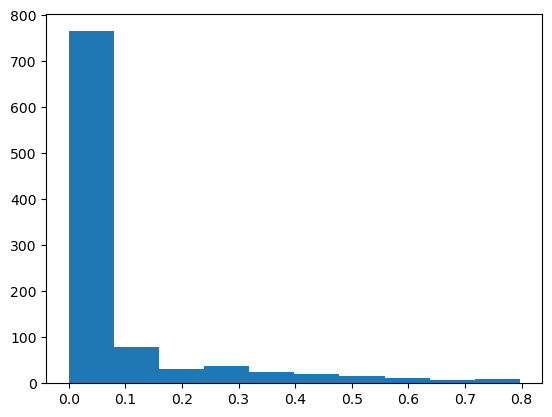

In [169]:
plt.hist(train_rsquareds)

In [195]:
ridge_regressor = Lasso()
ridge_regressor.fit(scaled_a_b[:-1, :], scaled_targets[:-1, 0])
ridge_regressor.score(scaled_a_b[:-1, :], scaled_targets[:-1, 0])

0.015626241773809002

In [196]:
np.where(np.abs(ridge_regressor.coef_)>0.0)

(array([602]),)

In [197]:
a_b_params_concat.iloc[:,[309, 602, 823]]

,MCK,CHTR,MOH
2024-08-13,0.000017,0.000579,0.000549
2024-08-14,-0.000002,0.000561,0.000440
2024-08-15,-0.000068,0.000505,0.000467
2024-08-16,0.000017,0.000435,0.000415
2024-08-19,-0.000010,0.000579,0.000434
2024-08-20,-0.000005,0.000540,0.000409
2024-08-21,0.000093,0.000460,0.000424
2024-08-22,-0.000021,0.000540,0.000519
2024-08-23,-0.000078,0.000633,0.000282
2024-08-26,-0.000070,0.000561,0.000402


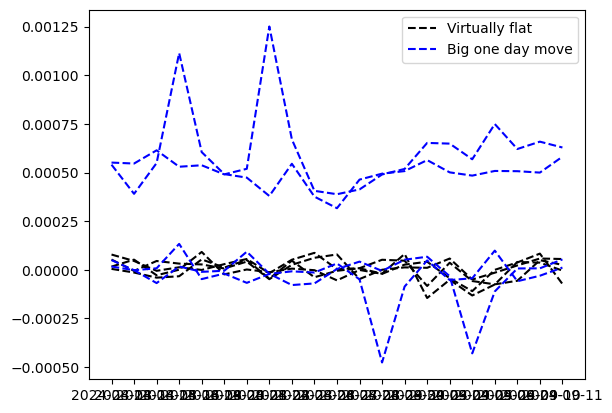

In [203]:
plt.plot(a_b_params_concat.iloc[:,0], ls = '--', color='black', label = 'Virtually flat')
plt.plot(a_b_params_concat.iloc[:,1], ls = '--',color='black')
plt.plot(a_b_params_concat.iloc[:,3], ls = '--',color='black')
plt.plot(a_b_params_concat.iloc[:,4], ls = '--',color='black')

plt.plot(a_b_params_concat.iloc[:,149], ls = '--', color='blue', label = 'Big one day move')
plt.plot(a_b_params_concat.iloc[:,309], ls = '--',color='blue')
plt.plot(a_b_params_concat.iloc[:,510], ls = '--',color='blue')
plt.plot(a_b_params_concat.iloc[:,524], ls = '--',color='blue')



plt.legend()



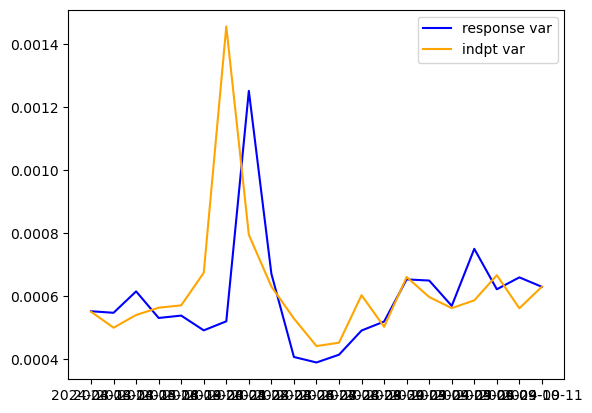

In [207]:
plt.plot(a_b_params_concat.iloc[:,510],color='blue', label = 'response var')
plt.plot(a_b_params_concat.iloc[:,774],color='orange', label = 'indpt var')
plt.legend()

In [175]:
a_b_params_concat.iloc[:,586]

2024-08-13    0.000654
2024-08-14    0.001455
2024-08-15    0.000964
2024-08-16    0.000608
2024-08-19    0.000454
2024-08-20    0.000526
2024-08-21    0.000435
2024-08-22    0.000445
2024-08-23    0.000457
2024-08-26    0.000328
2024-08-27    0.000429
2024-08-28    0.000407
2024-08-29    0.000446
2024-08-30    0.000443
2024-09-03    0.000621
2024-09-04    0.000531
2024-09-05    0.000697
2024-09-06    0.000609
2024-09-09    0.000539
2024-09-10    0.000584
2024-09-11    0.000523
Name: CAH, dtype: float64

In [202]:
np.where(np.asarray(train_rsquareds)>0.6)

(array([ 149,  309,  510,  524,  563,  586,  602,  607,  610,  625,  633,
         665,  696,  739,  755,  810,  823,  842,  911,  924,  936, 1000]),)

In [205]:
np.where(np.abs(ridge_regressor.coef_)>0.0)

(array([774]),)

In [147]:
a_b_params_concat.iloc[:,209]

2024-08-13    0.000061
2024-08-14   -0.000044
2024-08-15    0.000080
2024-08-16   -0.000007
2024-08-19    0.000054
2024-08-20   -0.000074
2024-08-21   -0.000012
2024-08-22   -0.000008
2024-08-23   -0.000013
2024-08-26   -0.000008
2024-08-27   -0.000007
2024-08-28   -0.000032
2024-08-29   -0.000010
2024-08-30    0.000015
2024-09-03    0.000016
2024-09-04    0.000203
2024-09-05   -0.000005
2024-09-06   -0.000127
2024-09-09   -0.000015
2024-09-10    0.000019
2024-09-11    0.000115
Name: GEHC, dtype: float64

In [151]:
a_b_params_concat.iloc[:,209+501]

2024-08-13    0.000509
2024-08-14    0.000512
2024-08-15    0.000552
2024-08-16    0.000483
2024-08-19    0.000414
2024-08-20    0.000468
2024-08-21    0.000426
2024-08-22    0.000418
2024-08-23    0.000676
2024-08-26    0.000481
2024-08-27    0.000379
2024-08-28    0.000580
2024-08-29    0.000649
2024-08-30    0.000489
2024-09-03    0.000657
2024-09-04    0.000679
2024-09-05    0.000810
2024-09-06    0.000728
2024-09-09    0.000626
2024-09-10    0.000480
2024-09-11    0.000818
Name: GEHC, dtype: float64

In [204]:
ridge_regressor = Lasso()
ridge_regressor.fit(scaled_a_b[:-1], scaled_targets[:-1, 510])
ridge_regressor.score(scaled_a_b[:-1], scaled_targets[:-1, 510])


0.6282716154906127

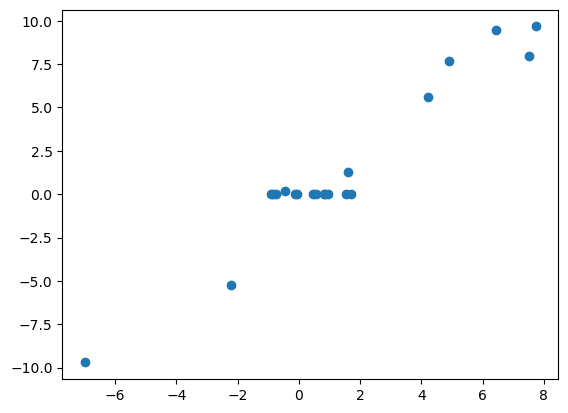

In [125]:
plt.scatter(ridge_regressor.predict(scaled_a_b[:-1]), scaled_targets[:-1,57])

In [122]:
np.where(np.abs(ridge_regressor.coef_)>0)

(array([ 57,  88, 109, 155, 200, 253, 280, 313, 379, 386, 422, 602, 607,
        633, 696]),)

In [124]:
a_params_df.corr().iloc[0].values[:30]

array([ 1.        , -0.1622869 , -0.34763674, -0.04480993,  0.10538489,
        0.29651294,  0.5065919 ,  0.25186641,  0.00519172,  0.19359778,
        0.05203881,  0.39447392,  0.08581442,  0.12665639,  0.55570363,
        0.0919945 ,  0.20526645, -0.38752465, -0.40391656,  0.34264077,
        0.36376981,  0.24393636,  0.46227674,         nan, -0.08077961,
        0.46142384, -0.07960296,  0.21437372,  0.35495953, -0.0435434 ])

In [126]:
a_params_df.corr().iloc[0, 23]

np.float64(nan)

In [127]:
a_params_df.iloc[:,23]

2024-07-15_b    0.0
2024-07-16_b    0.0
2024-07-17_b    0.0
2024-07-18_b    0.0
2024-07-19_b    0.0
2024-07-22_b    0.0
2024-07-23_b    0.0
2024-07-24_b    0.0
2024-07-25_b    0.0
2024-07-26_b    0.0
2024-07-29_b    0.0
2024-07-30_b    0.0
2024-07-31_b    0.0
2024-08-01_b    0.0
2024-08-02_b    0.0
2024-08-05_b    0.0
2024-08-06_b    0.0
2024-08-07_b    0.0
2024-08-08_b    0.0
2024-08-09_b    0.0
2024-08-12_b    0.0
2024-08-13_b    0.0
2024-08-14_b    0.0
2024-08-15_b    0.0
2024-08-16_b    0.0
2024-08-19_b    0.0
2024-08-20_b    0.0
2024-08-21_b    0.0
2024-08-22_b    0.0
2024-08-23_b    0.0
2024-08-26_b    0.0
Name: AMCR, dtype: float64

In [115]:
a_params_df.dropna()

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2024-07-15_b,-9.687768e-05,0.000000,-2.331647e-05,-0.000030,0.000094,-0.000018,-0.000111,0.000000,0.000000,-0.000076,...,-0.000171,-0.000116,0.0,-1.181797e-04,0.000000,-0.000072,-0.000077,0.000000,0.000000,0.000000
2024-07-16_b,4.832349e-05,0.000000,0.000000e+00,-0.000006,0.000093,0.000000,-0.000057,0.000000,0.000000,0.000000,...,0.000000,-0.000118,0.0,5.790646e-07,0.000000,0.000000,0.000000,0.000000,-0.000047,0.000076
2024-07-17_b,4.781946e-05,0.000000,-4.756250e-05,0.000114,0.000046,-0.000033,-0.000062,0.000000,0.000000,-0.000075,...,0.000003,0.000000,0.0,0.000000e+00,0.000090,-0.000072,0.000000,0.000000,0.000000,0.000000
2024-07-18_b,9.523577e-05,-0.000110,0.000000e+00,-0.000114,-0.000030,0.000004,-0.000256,0.000000,0.000000,-0.000075,...,0.000000,0.000000,0.0,-1.179706e-04,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000028
2024-07-19_b,0.000000e+00,0.000000,4.915291e-05,-0.000058,0.000000,0.000009,0.000038,0.000000,-0.000107,0.000000,...,0.000000,0.000000,0.0,0.000000e+00,0.000090,0.000073,0.000000,0.000000,0.000091,0.000013
2024-07-22_b,9.571880e-05,0.000000,9.618132e-07,0.000000,0.000045,-0.000063,0.000065,0.000285,0.000000,-0.000038,...,0.000000,0.000000,0.0,2.996225e-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-07-23_b,0.000000e+00,0.000000,6.010630e-05,0.000000,0.000015,-0.000032,-0.000129,0.000000,0.000000,-0.000151,...,0.000000,0.000000,0.0,1.285491e-06,0.000000,0.000000,-0.000079,0.000000,-0.000045,-0.000012
2024-07-24_b,-4.828847e-05,-0.000061,1.428003e-04,0.000057,-0.000030,-0.000092,-0.000272,0.000000,-0.000053,0.000000,...,0.000000,-0.000117,0.0,-6.200493e-05,0.000090,-0.000073,0.000000,0.000000,0.000000,0.000042
2024-07-25_b,0.000000e+00,0.000000,-4.677653e-05,0.000082,-0.000015,0.000051,-0.000124,0.000000,0.000000,-0.000073,...,0.000003,0.000000,0.0,0.000000e+00,0.000000,-0.000036,0.000039,0.000000,0.000000,0.000024
2024-07-26_b,3.302586e-04,0.000000,-4.753065e-05,0.000000,0.000000,0.000080,0.000108,0.000000,-0.000018,0.000000,...,0.000160,0.000000,0.0,0.000000e+00,0.000087,0.000000,0.000039,0.000000,0.000000,0.000000


In [98]:
np.linalg.eig(b_params_df.corr().values)

EigResult(eigenvalues=array([ 2.82067148e+02+0.00000000e+00j,  2.93601788e+01+0.00000000e+00j,
        2.16918260e+01+0.00000000e+00j,  1.83036637e+01+0.00000000e+00j,
        1.47469817e+01+0.00000000e+00j,  1.35596558e+01+0.00000000e+00j,
        1.09565369e+01+0.00000000e+00j,  1.08999421e+01+0.00000000e+00j,
        9.14777006e+00+0.00000000e+00j,  8.83399100e+00+0.00000000e+00j,
        7.99389879e+00+0.00000000e+00j,  7.32549484e+00+0.00000000e+00j,
        6.82796623e+00+0.00000000e+00j,  6.55189596e+00+0.00000000e+00j,
        5.75451106e+00+0.00000000e+00j,  5.02497743e+00+0.00000000e+00j,
        4.96975038e+00+0.00000000e+00j,  4.68198624e+00+0.00000000e+00j,
        4.12434683e+00+0.00000000e+00j,  3.76628836e+00+0.00000000e+00j,
        3.48665916e+00+0.00000000e+00j,  3.30509564e+00+0.00000000e+00j,
        2.93541191e+00+0.00000000e+00j,  2.80000850e+00+0.00000000e+00j,
        2.28425536e+00+0.00000000e+00j,  2.17203031e+00+0.00000000e+00j,
        1.91244115e+00+0.0000

In [99]:
for column in a_params_df.columns:
    for i in range(15):
    a_params_df['shifted_1_'+column] = a_params_df[column].shift(1)
    b_params_df['shifted_1_'+column] = b_params_df[column].shift(1)


/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_3786/3099958085.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  a_params_df['shifted_'+column] = a_params_df[column].shift(1)
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_3786/3099958085.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  b_params_df['shifted_'+column] = b_params_df[column].shift(1)
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_3786/3099958085.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

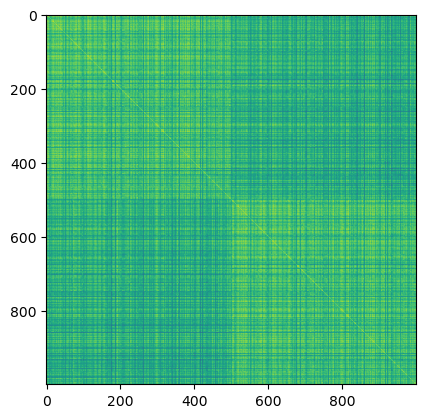

In [102]:
plt.imshow(b_params_df.corr())


In [ ]:
np.

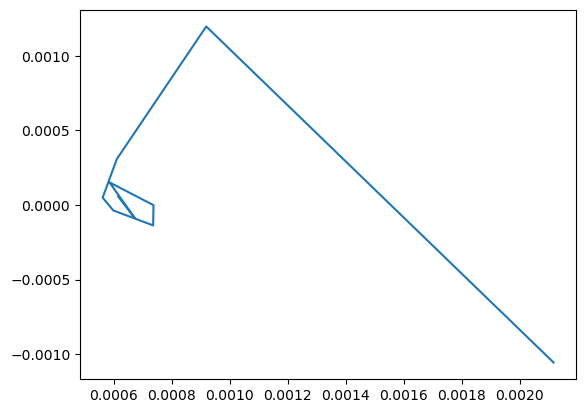

In [109]:
plt.plot(b_params_df['MMM'].values[:-1][:10], np.diff(b_params_df['MMM'].values)[:10])

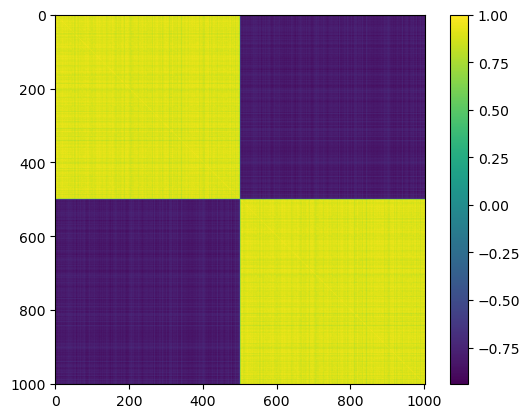

In [56]:
plt.imshow(ab_params_df.corr())
plt.colorbar()

In [59]:
eigenvalues, eigenvectors = np.linalg.eig(ab_params_df.corr().values)

(0.0, 10.0)

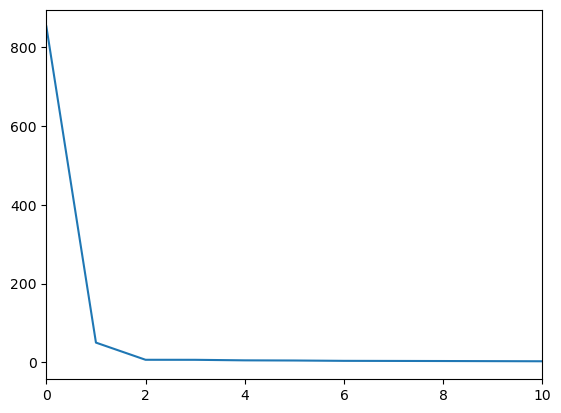

In [61]:
plt.plot(eigenvalues)
plt.xlim((0,10))


In [24]:
ticker_hist

,Date,Open,High,Low,Close,Adj Close,Volume


In [166]:
ticker = yf.Ticker('SPY')

#options_chain = ticker.option_chain('2024-08-30')
#calls = options_chain[0]
#puts = options_chain[1]

#end_date = datetime.datetime.now()
#start_date = end_date - datetime.timedelta(59)


ticker_hist = ticker.history(interval = '2m', start = start_date ,end=end_date)

ticker_hist = ticker_hist.reset_index()

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

counts, bin_edges = np.histogram(ticker_hist['logReturns'], bins=100)



In [189]:
counts, bin_edges = np.histogram(ticker_hist[ticker_hist['Date']!=datetime.date(2024, 8, 26)]['logReturns'], bins=100)

a = np.median(ticker_hist[ticker_hist['Date']<datetime.date(2024, 8, 26)]['logReturns'])
b = np.mean(np.absolute(ticker_hist[ticker_hist['Date']<datetime.date(2024, 8, 26)]['logReturns'] - a))

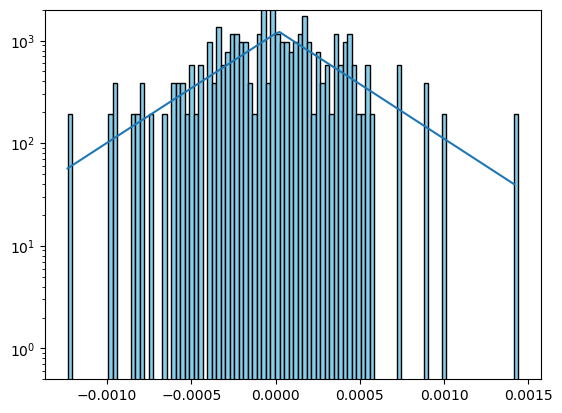

In [190]:
counts, bin_edges = np.histogram(ticker_hist[ticker_hist['Date']>=datetime.date(2024, 8, 26)]['logReturns'], bins=100)


plt.bar(
    x=bin_edges[:-1] + np.diff(bin_edges)[0]/2, 
    height=counts/(sum(counts)*np.diff(bin_edges)[0]),
    width=np.diff(bin_edges), 
    align='edge', 
    fc='skyblue', 
    ec='black'
)
#plt.xlim((bin_edges[0], bin_edges[-1]))
plt.plot(bin_edges[:-1] + np.diff(bin_edges)[0]/2, laplace_fit(bin_edges[:-1] + np.diff(bin_edges)[0]/2 , b, a))
plt.ylim(0.5, 2000)
plt.yscale('log')